# Learning-rate experiment

This notebook includes three training runs for the advanced model with three different **learning rates**:
- `1e-3`
- `1e-4`
- `1e-5`

In [20]:
from pathlib import Path
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.train import TrainConfig, run_training
from src.data import get_dataloaders
from src.evaluate import evaluate_model, load_models
from src.message_metrics import logits_to_bits

DATA_DIR = PROJECT_ROOT / 'data'
SPLITS_FILE = DATA_DIR / 'splits.json'
CHECKPOINT_ROOT = PROJECT_ROOT / 'results' / 'checkpoints'
LOG_ROOT = PROJECT_ROOT / 'results' / 'logs'

## Configuration

We will use the same training parameters used in the previous experiments, as they proved adequate for this model. The only parameter changed between runs is the learning rate.

In [13]:
HARD_ATTACKS = [
    {'name': 'none'},
    {'name': 'gaussian_noise', 'std': 0.01},
    {'name': 'gaussian_noise', 'std': 0.03},
    {'name': 'gaussian_blur', 'kernel_size': 3, 'sigma': 0.5},
    {'name': 'downscale', 'scale_factor': 0.75},
    {'name': 'rotation', 'angle': -2.0},
    {'name': 'rotation', 'angle': 2.0},
    {'name': 'gaussian_noise', 'std': 0.05},
    {'name': 'gaussian_blur', 'kernel_size': 5, 'sigma': 1.0},
    {'name': 'downscale', 'scale_factor': 0.5},
    {'name': 'rotation', 'angle': -5.0},
    {'name': 'rotation', 'angle': 5.0},
]

LEARNING_RATES = (1e-3, 1e-4, 1e-5)
EPOCHS = 60
BATCH_SIZE = 16
NUM_WORKERS = 4

def create_config(learning_rate):
    rate_label = f'{learning_rate:.0e}'
    experiment_name = f'lr_experiment_{rate_label}'
    return TrainConfig(
        experiment_name=experiment_name,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        message_length=16,
        encoder_channels=40,
        decoder_channels=40,
        decoder_normalization='batch',
        encoder_max_delta=0.03,
        learning_rate=learning_rate,
        image_loss_weight=0.0,
        device='cuda',
        checkpoint_dir=str(CHECKPOINT_ROOT),
        log_path=str(LOG_ROOT / f'{experiment_name}.csv'),
        attack_configs=HARD_ATTACKS,
        validation_attack_configs=HARD_ATTACKS,
        print_every=1,
        checkpoint_metric='ber',
        architecture='advanced',
    )

configs = [create_config(rate) for rate in LEARNING_RATES]
pd.DataFrame([
    {
        'experiment_name': config.experiment_name,
        'learning_rate': config.learning_rate,
        'epochs': config.epochs,
        'batch_size': config.batch_size,
        'device': config.device,
        'num_workers': NUM_WORKERS,
    }
    for config in configs
])

,experiment_name,learning_rate,epochs,batch_size,device,num_workers
0,lr_experiment_1e-03,0.00100,60,16,cuda,4
1,lr_experiment_1e-04,0.00010,60,16,cuda,4
2,lr_experiment_1e-05,0.00001,60,16,cuda,4


## Training

We will run the training for all three learning rates and gather results for comparison.

In [3]:

for config in configs:
    print(f'\nStarting {config.experiment_name} with learning rate {config.learning_rate:g}')
    _, _, history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=config, num_workers=NUM_WORKERS, shuffle_train=True)


Starting lr_experiment_1e-03 with learning rate 0.001
Epoch 1/60 | train_loss=0.6814 | train_BER=0.4527 | train_exact=0.0000 | val_loss=0.6798 | val_BER=0.4552 | val_exact=0.0000 | val_PSNR=32.73 | 82.9s
Epoch 2/60 | train_loss=0.6671 | train_BER=0.4193 | train_exact=0.0000 | val_loss=0.6664 | val_BER=0.4090 | val_exact=0.0000 | val_PSNR=33.24 | 83.7s
Epoch 3/60 | train_loss=0.6595 | train_BER=0.4042 | train_exact=0.0000 | val_loss=0.6735 | val_BER=0.4280 | val_exact=0.0000 | val_PSNR=32.60 | 84.1s
Epoch 4/60 | train_loss=0.6492 | train_BER=0.3952 | train_exact=0.0003 | val_loss=0.6536 | val_BER=0.4081 | val_exact=0.0000 | val_PSNR=32.31 | 84.5s
Epoch 5/60 | train_loss=0.6397 | train_BER=0.3968 | train_exact=0.0000 | val_loss=0.7526 | val_BER=0.4681 | val_exact=0.0000 | val_PSNR=32.09 | 83.8s
Epoch 6/60 | train_loss=0.6289 | train_BER=0.3955 | train_exact=0.0005 | val_loss=0.6579 | val_BER=0.4174 | val_exact=0.0000 | val_PSNR=32.02 | 84.9s
Epoch 7/60 | train_loss=0.6157 | train_BER=0.

## Results

First, we will visualize the training data for all three learning rates. For each experiment, we will plot the training and validation loss, BER, whole-message accuracy and image PSNR across epochs. We will then compare the best validation BER, exact accuracy and PSNR to determine which learning rate performs best.

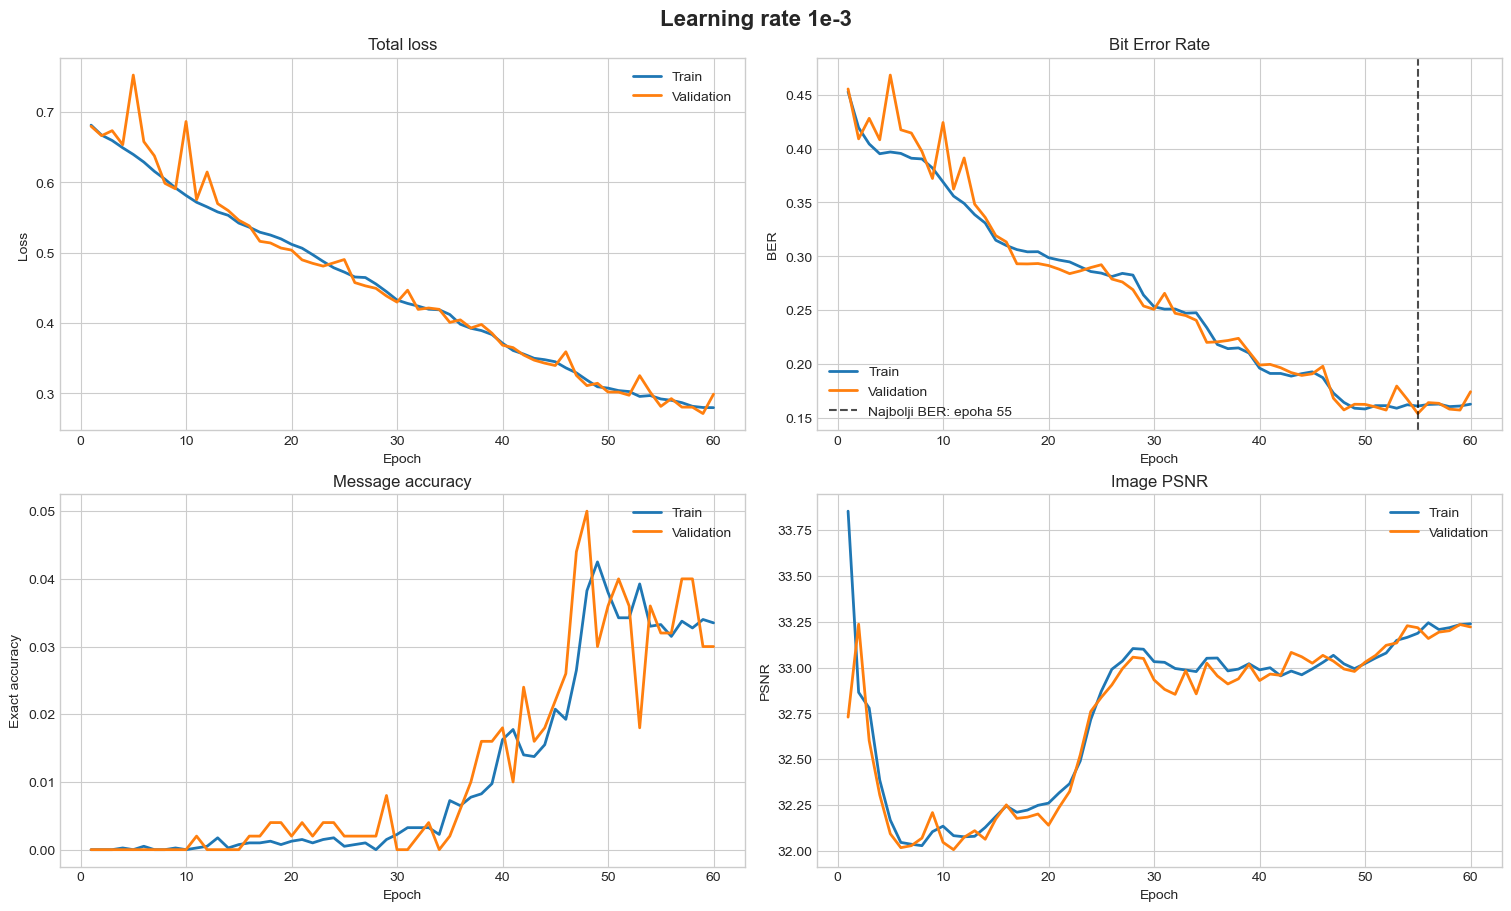

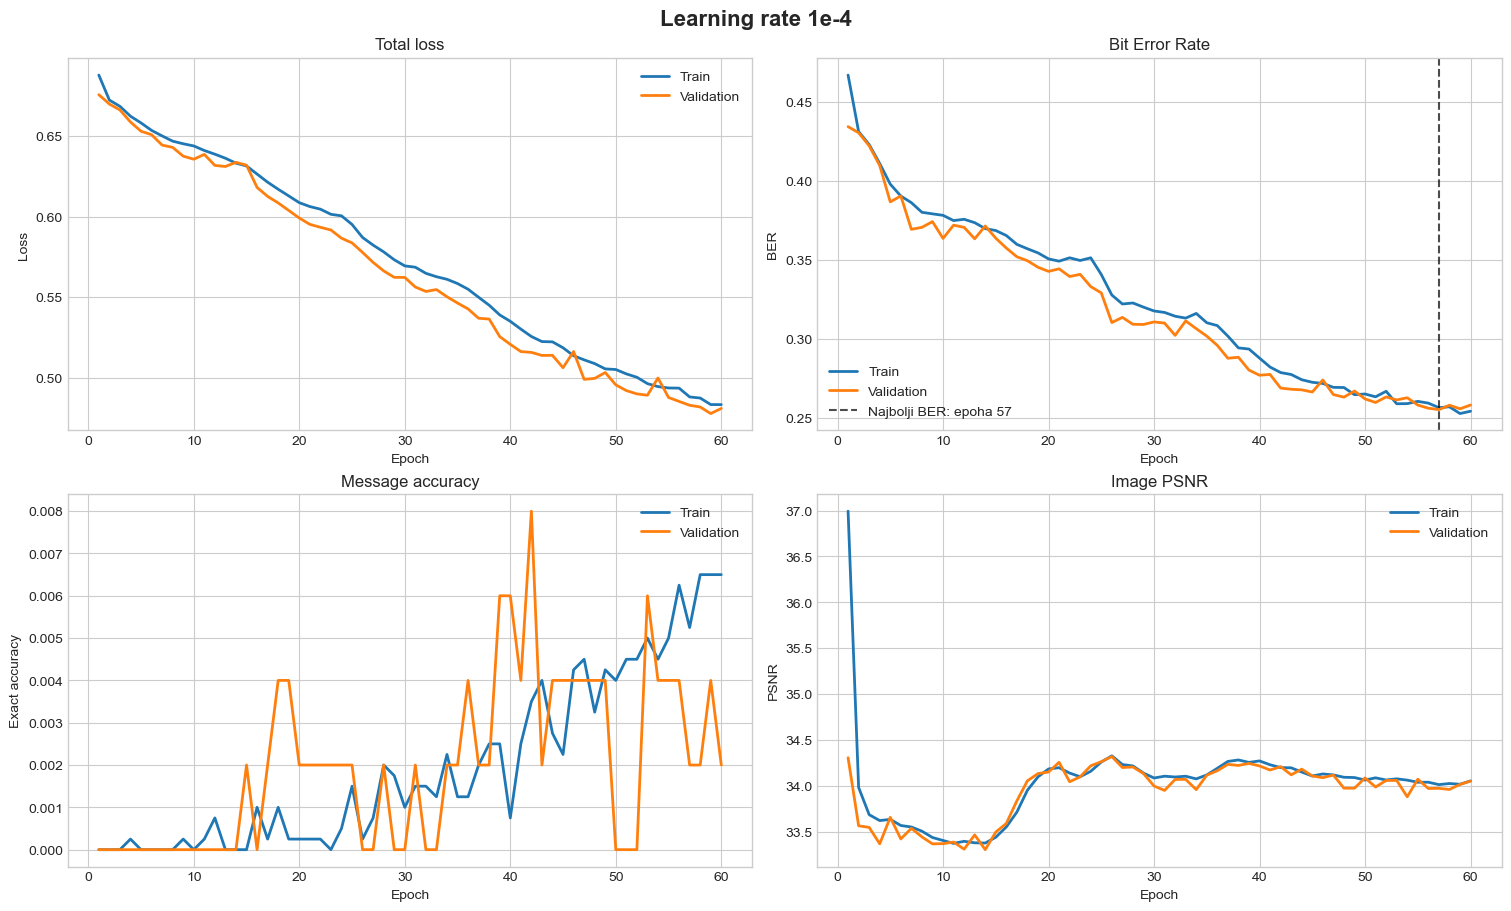

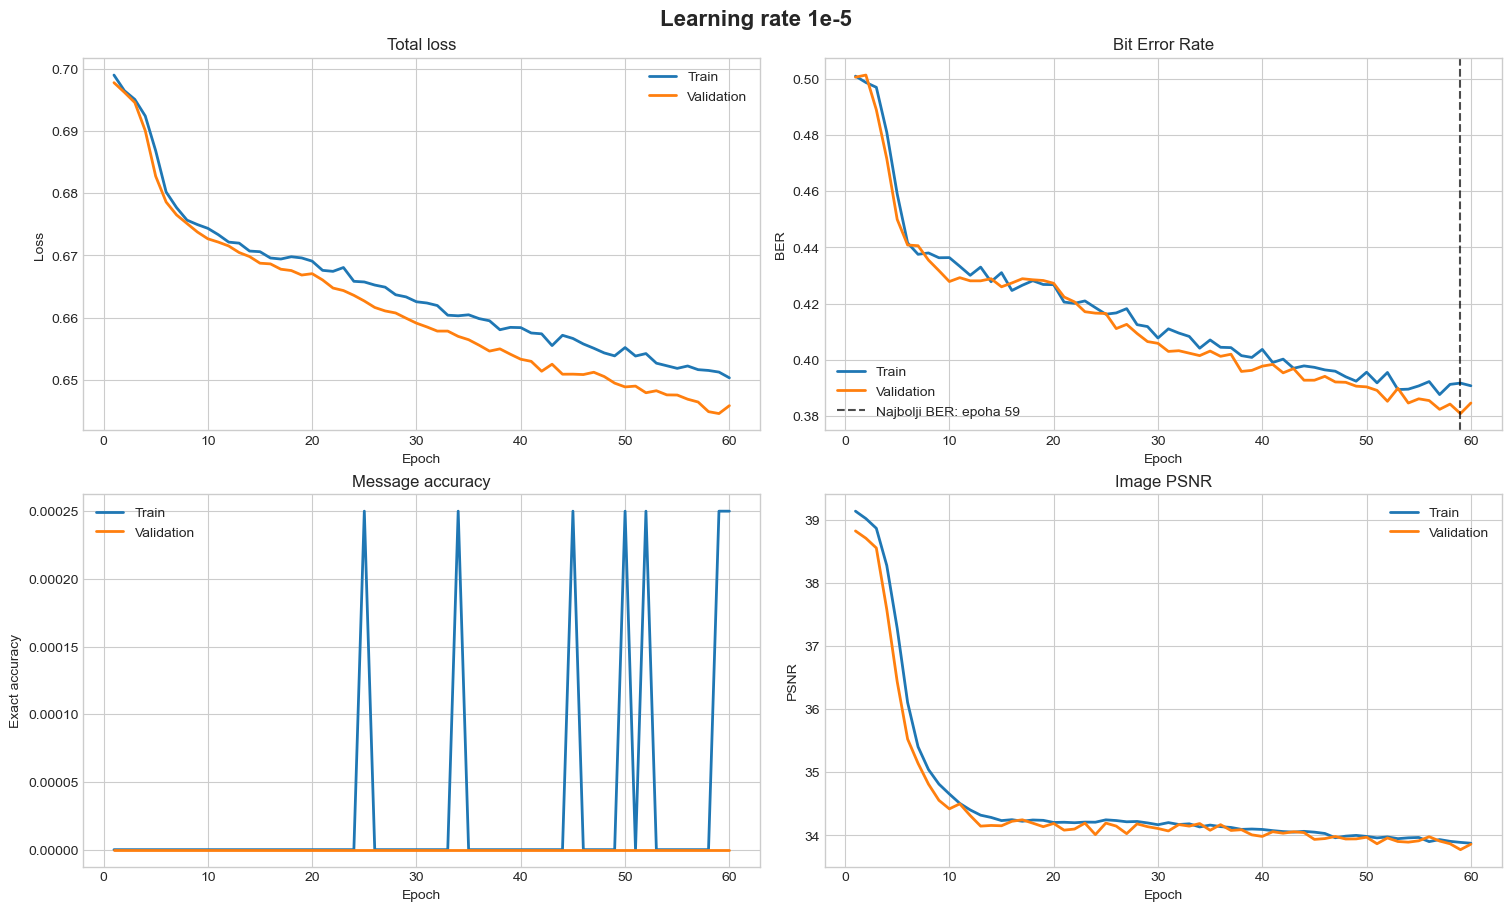

Experiment comparison


,learning_rate,best_epoch,best_val_ber,best_val_exact_accuracy,best_val_psnr,final_val_ber,final_val_exact_accuracy,final_val_psnr
0,1e-3,55,0.1542,3.20%,33.22,0.1745,3.00%,33.22
1,1e-4,57,0.2554,0.20%,33.97,0.2582,0.20%,34.05
2,1e-5,59,0.3809,0.00%,33.77,0.3846,0.00%,33.86


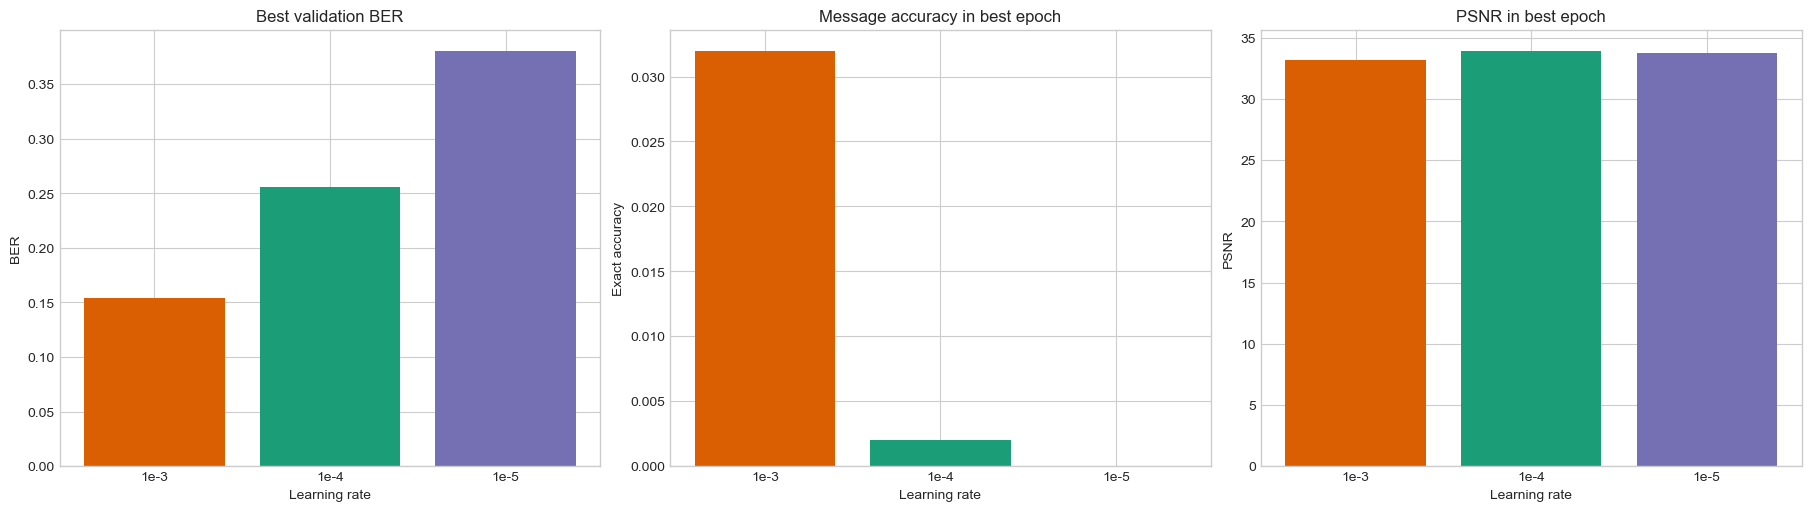

In [15]:
CHECKPOINT_DIR = PROJECT_ROOT / "results" / "checkpoints"
EXPERIMENTS = {
    "1e-3": LOG_DIR / "lr_experiment_1e-03.csv",
    "1e-4": LOG_DIR / "lr_experiment_1e-04.csv",
    "1e-5": LOG_DIR / "lr_experiment_1e-05.csv",
}

plt.style.use("seaborn-v0_8-whitegrid")
summary_rows = []

for learning_rate, log_path in EXPERIMENTS.items():
    if not log_path.exists():
        raise FileNotFoundError(f"File missing: {log_path}")

    history = pd.read_csv(log_path)
    best_index = history["val_ber"].idxmin()
    best = history.loc[best_index]
    last = history.iloc[-1]
    checkpoint_name = log_path.stem.replace("lr_experiment_", "")
    checkpoint_path = CHECKPOINT_DIR / f"lr_experiment_{checkpoint_name}" / "best_model.pt"

    summary_rows.append({
        "learning_rate": learning_rate,
        "best_epoch": int(best["epoch"]),
        "best_val_ber": best["val_ber"],
        "best_val_exact_accuracy": best["val_exact_accuracy"],
        "best_val_psnr": best["val_psnr"],
        "final_val_ber": last["val_ber"],
        "final_val_exact_accuracy": last["val_exact_accuracy"],
        "final_val_psnr": last["val_psnr"]
    })

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    fig.suptitle(f"Learning rate {learning_rate}", fontsize=16, fontweight="bold")

    axes[0, 0].plot(history["epoch"], history["train_loss"], label="Train", linewidth=2)
    axes[0, 0].plot(history["epoch"], history["val_loss"], label="Validation", linewidth=2)
    axes[0, 0].set_title("Total loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(history["epoch"], history["train_ber"], label="Train", linewidth=2)
    axes[0, 1].plot(history["epoch"], history["val_ber"], label="Validation", linewidth=2)
    axes[0, 1].axvline(best["epoch"], color="black", linestyle="--", alpha=0.7, label=f"Najbolji BER: epoha {int(best['epoch'])}")
    axes[0, 1].set_title("Bit Error Rate")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("BER")
    axes[0, 1].legend()

    axes[1, 0].plot(history["epoch"], history["train_exact_accuracy"], label="Train", linewidth=2)
    axes[1, 0].plot(history["epoch"], history["val_exact_accuracy"], label="Validation", linewidth=2)
    axes[1, 0].set_title("Message accuracy")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Exact accuracy")
    axes[1, 0].legend()

    axes[1, 1].plot(history["epoch"], history["train_psnr"], label="Train", linewidth=2)
    axes[1, 1].plot(history["epoch"], history["val_psnr"], label="Validation", linewidth=2)
    axes[1, 1].set_title("Image PSNR")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("PSNR")
    axes[1, 1].legend()

    plt.show()

summary = pd.DataFrame(summary_rows)
print("Experiment comparison")
display(summary.style.format({
    "best_val_ber": "{:.4f}",
    "best_val_exact_accuracy": "{:.2%}",
    "best_val_psnr": "{:.2f}",
    "final_val_ber": "{:.4f}",
    "final_val_exact_accuracy": "{:.2%}",
    "final_val_psnr": "{:.2f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
labels = summary["learning_rate"]

axes[0].bar(labels, summary["best_val_ber"], color=["#d95f02", "#1b9e77", "#7570b3"])
axes[0].set_title("Best validation BER")
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("BER")

axes[1].bar(labels, summary["best_val_exact_accuracy"], color=["#d95f02", "#1b9e77", "#7570b3"])
axes[1].set_title("Message accuracy in best epoch")
axes[1].set_xlabel("Learning rate")
axes[1].set_ylabel("Exact accuracy")

axes[2].bar(labels, summary["best_val_psnr"], color=["#d95f02", "#1b9e77", "#7570b3"])
axes[2].set_title("PSNR in best epoch")
axes[2].set_xlabel("Learning rate")
axes[2].set_ylabel("PSNR")

plt.show()

We will evaluate the results using **validation BER**, because a lower BER means fewer errors when reconstructing the watermark message.

| **Learning rate** | **Best epoch** | **Best validation BER** | **Exact accuracy** | **PSNR** |
|---|---:|---:|---:|---:|
| `1e-3` | 55 | 0.15425 | 3.20% | 33.22 dB |
| `1e-4` | 57 | 0.25538 | 0.20% | 33.97 dB |
| `1e-5` | 59 | 0.38088 | 0.00% | 33.77 dB |

The learning rate `1e-3` produces the best watermark reconstruction quality because it achieves the **lowest BER** and the **highest whole-message accuracy**. The `1e-4` experiment achieves a slightly higher **image PSNR**, but this does not result in better watermark reconstruction, so PSNR alone is not enough for choosing the best model. The smallest learning rate (`1e-5`) learns too slowly since its validation BER remains the highest and its exact accuracy is 0%.

For this architecture and dataset, `1e-3` **learning rate** is the best choice among the three tested rates. We will test this model on the test subset.

In [29]:
best_learning_rate = "1e-3"
checkpoint_path = PROJECT_ROOT / "results" / "checkpoints" / "lr_experiment_1e-03" / "best_model.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder, decoder, checkpoint_config = load_models(checkpoint_path, device)
_, _, test_loader = get_dataloaders(data_dir=DATA_DIR, splits_file=SPLITS_FILE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle_train=False)

if test_loader is None:
    raise ValueError("The test data loader could not be created.")

message_length = checkpoint_config["message_length"]
test_metrics = evaluate_model(encoder=encoder, decoder=decoder, loader=test_loader, device=device, message_length=message_length)

metrics_table = pd.DataFrame([{
    "Learning rate": best_learning_rate,
    "Number of images": test_metrics["num_images"],
    "Message loss": test_metrics["message_loss"],
    "BER": test_metrics["ber"],
    "Exact accuracy": test_metrics["exact_accuracy"],
    "MSE": test_metrics["mse"],
    "PSNR (dB)": test_metrics["psnr"],
    "SSIM": test_metrics["ssim"]
}])

display(metrics_table.style.format({
    "Message loss": "{:.4f}",
    "BER": "{:.4f}",
    "Exact accuracy": "{:.2%}",
    "MSE": "{:.6f}",
    "PSNR (dB)": "{:.4f}",
    "SSIM": "{:.4f}",
    "Number of images": "{:.0f}"
}))

,Learning rate,Number of images,Message loss,BER,Exact accuracy,MSE,PSNR (dB),SSIM
0,1e-3,500,0.2702,0.1515,3.60%,0.000479,33.1972,0.9175


The selected model with learning rate `1e-3` achieves a test BER of `0.1515` and an exact message accuracy of `3.60%`, showing that it recovers many individual watermark bits but rarely reconstructs the complete 16-bit message correctly. The watermarked images remain visually close to the originals, with an MSE of `0.000479`, a PSNR of `33.1972 dB`, and an SSIM of `0.9175`. Overall, the model preserves image quality reasonably well, but message reconstruction remains the main limitation on the test set.